In [3]:
import pandas as pd

df = pd.read_csv('grades.csv')  # Replace with your file path
print(df.head())

#this reads the file into a dataframe within pandas

  FP130 FP130X HE111 HE111S HE111W HE111X HE112 HE112S HE112V HE112W  ...  \
0     V    NaN     V    NaN    NaN    NaN   NaN    NaN     A-    NaN  ...   
1     A    NaN     A    NaN    NaN    NaN     A    NaN    NaN    NaN  ...   
2   NaN      A     V    NaN    NaN    NaN   NaN    NaN    NaN    NaN  ...   
3    C+    NaN    A-    NaN    NaN    NaN     B    NaN    NaN    NaN  ...   
4     B    NaN    A-    NaN    NaN    NaN     A    NaN    NaN    NaN  ...   

  SM221X SM223 SM239 SP211 SP211P SP211R SP212 SP212P SP212R SY110  
0    NaN   NaN   NaN   NaN      A    NaN     A    NaN    NaN     A  
1    NaN   NaN   NaN   NaN    NaN    NaN   NaN    NaN    NaN     A  
2    NaN   NaN   NaN   NaN    NaN    NaN   NaN    NaN    NaN     A  
3    NaN     C   NaN     B    NaN    NaN    B+    NaN    NaN     C  
4    NaN   NaN   NaN     B    NaN    NaN     B    NaN    NaN    B-  

[5 rows x 40 columns]


### Reading the data
This first block of code opens and reads the file. It provided a datafram for a general picture on the structure of the data. df will be used as the main object holding all the data.

In [4]:
grade_to_numeric = {
    "A": 95, "A-": 91,
    "B+": 88, "B": 85, "B-": 81,
    "C+": 78, "C": 75, "C-": 71,
    "D+": 68, "D": 65, "D-": 61,
    "F": 55 
    # ignore validations or anything that is not a grade
}

#this function takes the last part of the grade which comes into play when there are re-takes
def convert_grade(value):
    if pd.isna(value):
        return None
    # Split on ";" and take the last part (assuming last is the actual grade)
    last_part = str(value).split(";")[-1].strip()
    return grade_to_numeric.get(last_part, None)

#apply the grade converter to all cells
df_numeric = df.map(convert_grade)

# Compute medians
medians = df_numeric.median()
#make a pretty data frame with all the calculated medians
medians_df = medians.to_frame("Median (100-pt scale)")

print(medians_df)

        Median (100-pt scale)
FP130                    88.0
FP130X                   85.0
HE111                    91.0
HE111S                   91.0
HE111W                   88.0
HE111X                   93.0
HE112                    91.0
HE112S                   95.0
HE112V                   95.0
HE112W                   88.0
HH104                    88.0
HH104X                   85.0
HH215                    91.0
HH215A                   88.0
HH215M                   88.0
HH216                    91.0
NE203                    91.0
NL110                    91.0
NN220                    88.0
NS101                    85.0
SC111                    81.0
SC112                    78.0
SC112R                   75.0
SM121A                   78.0
SM122                    81.0
SM122R                   83.0
SM122X                   85.0
SM131                    65.0
SM221                    85.0
SM221P                   91.0
SM221X                   85.0
SM223                    85.0
SM239     

##
-

In [18]:
# Step 1: Clean grades (use last entry if multiple)
df_clean = df.map(extract_final_grade)

# Step 2: Valid grades (we only want those in mapping)
valid_grades = list(grade_to_numeric.keys())
df_clean = df_clean.map(lambda g: g if g in valid_grades else None)

# Step 3: Count D’s and F’s per class
risk_summary = []

for col in df_clean.columns:
    grades = df_clean[col].dropna()
    
    # Count only low grades
    low_count = grades.isin(["D+", "D", "D-", "F"]).sum()
    
    # Total students (valid grades only)
    total_students = len(grades)
    
    # Build row
    risk_summary.append({
        "Class": col,
        "Low_Grades (D/F)": low_count,
        "Total Students": total_students,
        "Percent Low": (low_count / total_students * 100) if total_students > 0 else 0
    })

# Step 4: Make DataFrame and rank
risk_df = pd.DataFrame(risk_summary)
risk_df = risk_df.sort_values("Low_Grades (D/F)", ascending=False).reset_index(drop=True)

risk_df.insert(0, "Rank", risk_df.index + 1)
risk_df = risk_df.reset_index(drop=True)

print(risk_df.head(3))  # top 10 riskiest classes

   Rank  Class  Low_Grades (D/F)  Total Students  Percent Low
0     1  SC112               808            5185    15.583414
1     2  SC111               660            5318    12.410681
2     3  SM122               599            4715    12.704136


In [16]:
# Step 1: Clean grades (use last entry if multiple)
df_clean = df.map(extract_final_grade)

# Step 2: Valid grades (we only want those in mapping)
valid_grades = list(grade_to_numeric.keys())
df_clean = df_clean.map(lambda g: g if g in valid_grades else None)

# Step 3: Count A’s per class
risk_summary = []

for col in df_clean.columns:
    grades = df_clean[col].dropna()
    
    # Count only low grades
    high_count = grades.isin(["A+", "A", "A-"]).sum()
    
    # Total students (valid grades only)
    total_students = len(grades)
    
    # Build row
    risk_summary.append({
        "Class": col,
        "High_Grades (A's!)": high_count,
        "Total Students": total_students,
        "Percent Low": (high_count / total_students * 100) if total_students > 0 else 0
    })

# Step 4: Make DataFrame and rank
risk_df = pd.DataFrame(risk_summary)
risk_df = risk_df.sort_values("High_Grades (A's!)", ascending=False).reset_index(drop=True)

risk_df.insert(0, "Rank", risk_df.index + 1)

print(risk_df.head(3))  # top 10 riskiest classes

   Rank  Class  High_Grades (A's!)  Total Students  Percent Low
0     1  NL110                3680            5753    63.966626
1     2  NE203                2868            4501    63.719174
2     3  HH104                2643            5665    46.654898


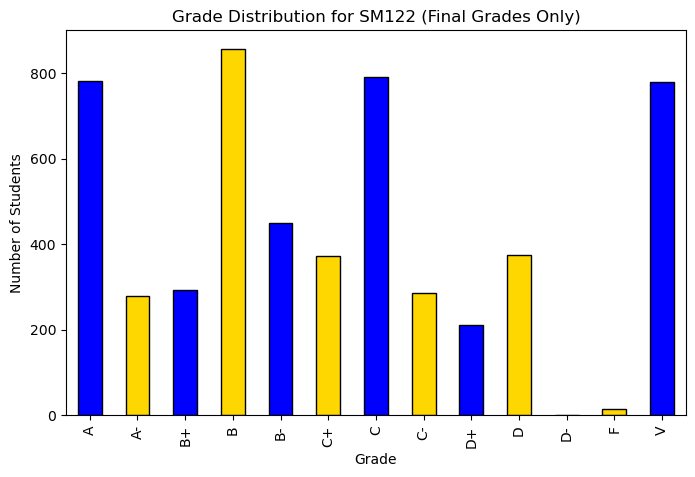

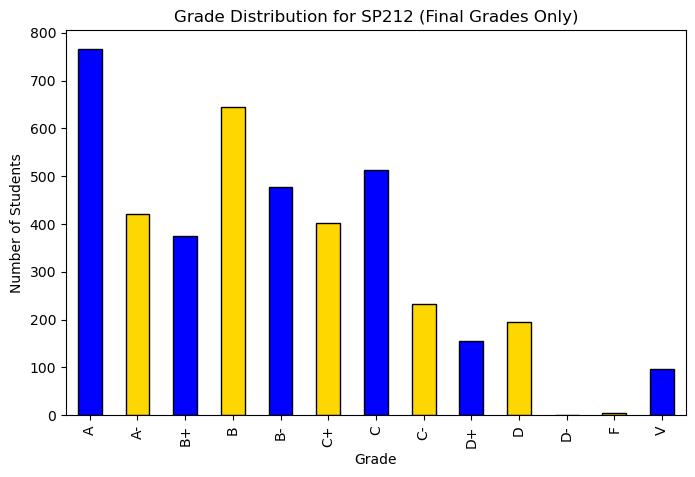

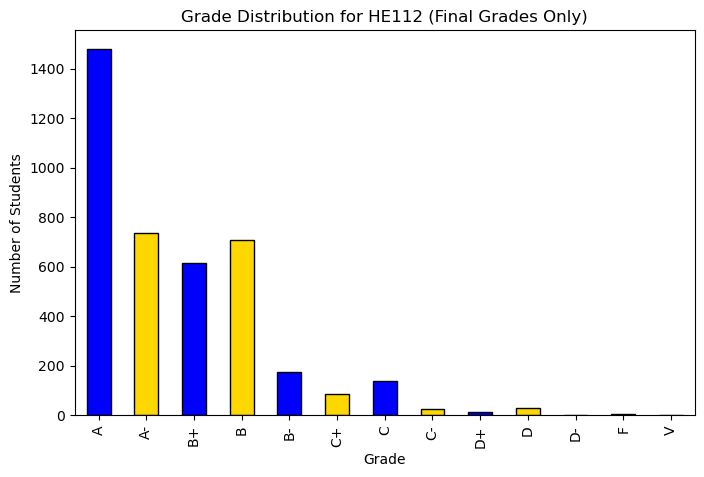

In [23]:
import matplotlib.pyplot as plt

valid_grades_with_v = list(grade_to_numeric.keys()) + ["V"]

# Build alternating colors list
colors = ["blue", "gold"] * (len(valid_grades_with_v) // 2 + 1)
colors = colors[:len(valid_grades_with_v)]  # trim to right length

def plot_class_histogram(df_clean, class_code):
    """Plot grade distribution for a given class with alternating blue/gold bars."""
    grades = df_clean[class_code].dropna()
    grades = grades[grades.isin(valid_grades_with_v)]
    
    counts = grades.value_counts().reindex(valid_grades_with_v, fill_value=0)
    
    plt.figure(figsize=(8, 5))
    counts.plot(
        kind="bar",
        color=colors,
        edgecolor="black"
    )
    plt.title(f"Grade Distribution for {class_code} (Final Grades Only)")
    plt.xlabel("Grade")
    plt.ylabel("Number of Students")
    plt.show()

# Plot for your three classes
plot_class_histogram(df_clean, "SM122")
plot_class_histogram(df_clean, "SP212")
plot_class_histogram(df_clean, "HE112")

#due to wanting to include validated grades, I chose to make the x-axis the letter grades versus a range

## Histograms for Three USNA Courses
The graphs above show hostograms for three different courses. It was chosen to make there be letter grades along the x-axis since our data did not provide decimals. Additionally, the validated classes were included to provide another data point for each class. A blue and gold color theme was given for USNA spirit.
